In [50]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 
import re

from factcheck.data import get_claims_and_labels, load_climate_fever

In [51]:
dataset = load_climate_fever()

claims, labels = get_claims_and_labels(dataset)

counts = pd.Series(labels).value_counts()

print(counts)

SUPPORTS           654
NOT_ENOUGH_INFO    474
REFUTES            253
DISPUTED           154
Name: count, dtype: int64


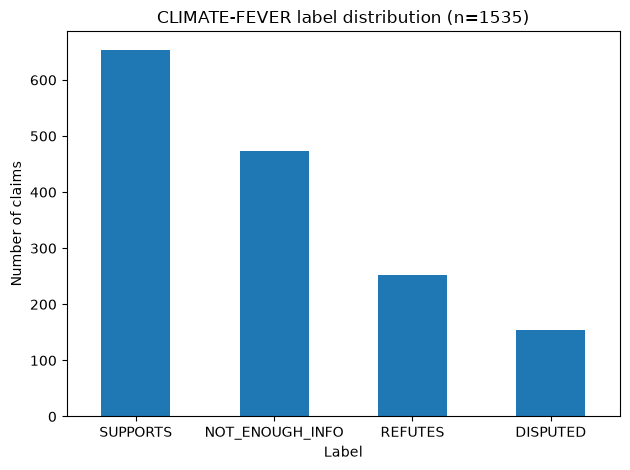

In [52]:
axis = counts.plot(kind="bar")
axis.set_xlabel("Label")
axis.set_ylabel("Number of claims")
axis.set_title("CLIMATE-FEVER label distribution (n=1535)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../figures/label_distribution.png", dpi=300)
plt.show()

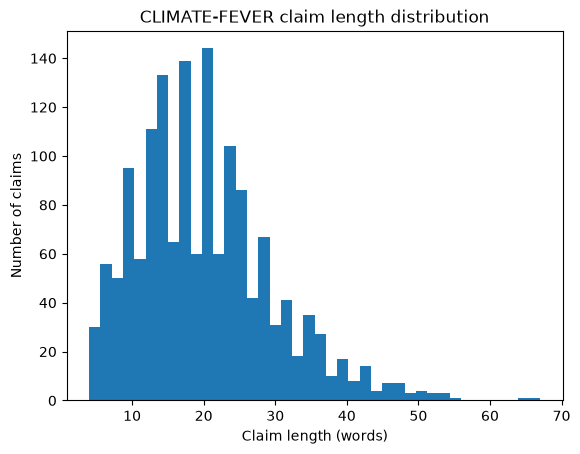

In [53]:
"""Why knowing length distribution is important:
DeBERTa NLI model has a maximum input length of 512 tokens shared between evidence and claim. 
Knowing the claims are, let's say <= 60, you will never see the claim side."""

claims, labels = get_claims_and_labels(load_climate_fever())

lengths = [len(c.split()) for c in claims] #length in words

plt.hist(lengths, bins=40)
plt.xlabel("Claim length (words)")
plt.ylabel("Number of claims")
plt.savefig("../figures/claim_length_distribution.png")
plt.title("CLIMATE-FEVER claim length distribution")
plt.show()

In [54]:
"""Getting the min/max/mean/median in one line"""

description = pd.Series(lengths).describe()
print(description.round(3))

count    1535.000
mean       20.191
std         9.553
min         4.000
25%        13.000
50%        19.000
75%        26.000
max        67.000
dtype: float64


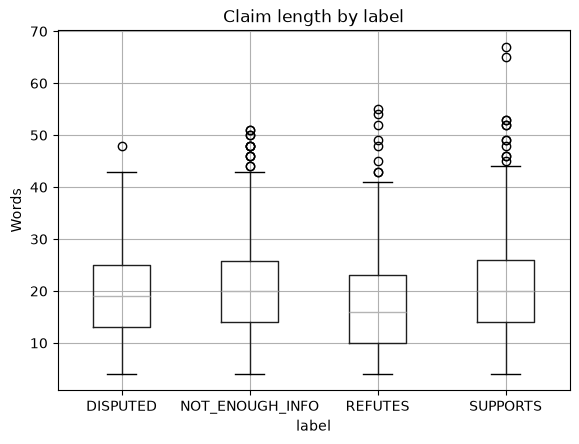

In [55]:
df = pd.DataFrame({"claim": claims, "label": labels, "length": lengths})
df.boxplot(column="length", by="label")
plt.title("Claim length by label")
plt.suptitle("")
plt.ylabel("Words")
plt.savefig("../figures/boxplot_claim_length_by_label.png")
plt.show()


In [56]:
"""Printing out the shortest and longest claims. 
When looking at the claims, some of them are duplicates, e.g., claim 737 and 1035."""
df["claim"] = claims
print(df.nsmallest(5, "length")[["length", "claim"]].to_string())
print(df.nlargest(5, "length")[["length", "claim"]].to_string())

      length                                      claim
737        4          Clouds provide negative feedback.
742        4        IPCC overestimate temperature rise.
779        4  Underground temperatures control climate.
1035       4           Clouds provide negative feedback
1042       4         IPCC overestimate temperature rise
      length                                                                                                                                                                                                                                                                                                                                                                                                                   claim
385       67                                                                            Or the news from Antarctica this past May, when a crack in an ice shelf grew 11 miles in six days, then kept going; the break now has just three miles to g

In [57]:
"""Finding duplicates and normalizing"""

def normalize(c):
    return re.sub(r"[^\w\s]", "", c.lower()).strip()

df["norm"] = df["claim"].map(normalize)
dupes = df[df["norm"].duplicated(keep=False)].sort_values("norm")
print(f"{len(dupes)} claims involved in duplicate groups")
print(dupes[["label", "claim"]].to_string())

88 claims involved in duplicate groups
                label                                                                                                                                                                                                                                                          claim
736   NOT_ENOUGH_INFO                                                                                                                                                                                                       2nd law of thermodynamics contradicts greenhouse theory.
1033  NOT_ENOUGH_INFO                                                                                                                                                                                                        2nd law of thermodynamics contradicts greenhouse theory
758           REFUTES                                                                                                             

In [58]:
"""Identical inputs with contradictory targets put a hard ceiling below 100%"""

group_labels = dupes.groupby("norm")["label"].nunique()
conflicting = group_labels[group_labels > 1]
print(f"{len(conflicting)} duplicate groups with conflicting labels.")

conflicting_rows = dupes[dupes["norm"].isin(conflicting.index)]
print(conflicting_rows.sort_values("norm")[["label", "claim"]].to_string())

15 duplicate groups with conflicting labels.
                label                                                                                                                                                                                                                                                          claim
760          DISPUTED                                                                                                                                                                                                      Adapting to global warming is cheaper than preventing it.
1061         SUPPORTS                                                                                                                                                                                                       Adapting to global warming is cheaper than preventing it
726           REFUTES                                                                                                       

In [60]:
"""Read 10 random claims per label"""

for label in df["label"].unique():
    print(f"\n==== {label} ====")
    sample = df[df["label"] == label].sample(10, random_state=42)
    for _, row in sample.iterrows():
        print("-", row["claim"])



==== SUPPORTS ====
- The natural cycle adds and removes CO2 to keep a balance; humans add extra CO2 without removing any.
- For the past 4567 million years, the sun and the Earth’s orbit have driven climate change cycles.
- Satellite and surface measurements find less energy is escaping to space at CO2 absorption wavelengths.
- Both the extent and thickness of Arctic sea ice has declined rapidly over the last several decades.
- Global sea level data shows that sea level rise has been increasing since 1880 while future sea level rise predictions are based on physics, not statistics.
- "Cloud cover in models is poorly treated and inaccurately predicted.
- Shelters in poorer countries are not repainted as often, and darker stations absorb more of the sun’s energy.
- The unusual heat was most noteworthy in Europe, which had its warmest April on record, and Australia, which had its second-warmest.
- Famine, economic collapse, a sun that cooks us: What climate change could wreak — sooner th